In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [2]:
print(torch.__version__)

2.13.0+cpu


In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cpu


In [4]:
basic_transform = transforms.Compose([
    transforms.ToTensor()
])

In [5]:
train_basic = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=basic_transform
)

test_basic = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=basic_transform
)

100.0%


In [6]:
print("Training images:", len(train_basic))
print("Testing images:", len(test_basic))

Training images: 50000
Testing images: 10000


In [7]:
train_loader_basic = DataLoader(
    train_basic,
    batch_size=64,
    shuffle=True
)

test_loader_basic = DataLoader(
    test_basic,
    batch_size=64,
    shuffle=False
)

In [8]:
print("Training batches:", len(train_loader_basic))
print("Testing batches:", len(test_loader_basic))

Training batches: 782
Testing batches: 157


In [9]:
augment_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

In [10]:
train_augmented = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=augment_transform
)

In [11]:
test_transform = transforms.Compose([
    transforms.ToTensor()
])

In [12]:
test_augmented = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

In [13]:
train_loader_augmented = DataLoader(
    train_augmented,
    batch_size=64,
    shuffle=True
)

test_loader_augmented = DataLoader(
    test_augmented,
    batch_size=64,
    shuffle=False
)

In [14]:
classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

In [15]:
image, label = train_augmented[0]

print("Class:", classes[label])
print("Shape:", image.shape)

Class: frog
Shape: torch.Size([3, 32, 32])


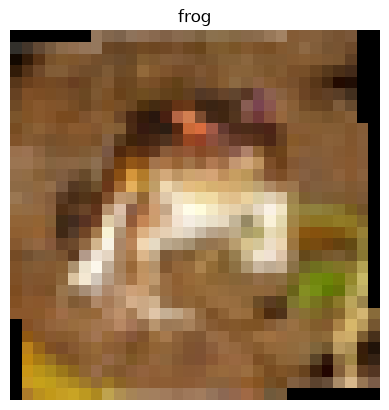

In [16]:
plt.imshow(image.permute(1, 2, 0))
plt.title(classes[label])
plt.axis("off")
plt.show()

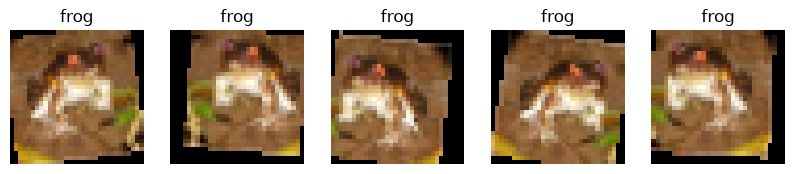

In [17]:
plt.figure(figsize=(10, 4))

for i in range(5):
    image, label = train_augmented[0]

    plt.subplot(1, 5, i + 1)
    plt.imshow(image.permute(1, 2, 0))
    plt.title(classes[label])
    plt.axis("off")

plt.show()

In [18]:
class SimpleCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [23]:
model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

# Freeze pretrained layers
for param in model.parameters():
    param.requires_grad = False

# Change final layer for CIFAR-10 (10 classes)
model.fc = nn.Linear(512, 10)

In [24]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

In [26]:
def train_model(model, train_loader, epochs=5):

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    losses = []

    for epoch in range(epochs):

        model.train()

        running_loss = 0.0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)

        losses.append(epoch_loss)

        print(
            f"Epoch [{epoch+1}/{epochs}], "
            f"Loss: {epoch_loss:.4f}"
        )

    return losses

In [27]:
def evaluate_model(model, test_loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    return accuracy

In [28]:
model_basic = SimpleCNN()

In [29]:
basic_losses = train_model(
    model_basic,
    train_loader_basic,
    epochs=5
)

Epoch [1/5], Loss: 1.4853
Epoch [2/5], Loss: 1.1174
Epoch [3/5], Loss: 0.9615
Epoch [4/5], Loss: 0.8617
Epoch [5/5], Loss: 0.7892


In [30]:
basic_accuracy = evaluate_model(
    model_basic,
    test_loader_basic
)

print(
    f"Accuracy without augmentation: "
    f"{basic_accuracy:.2f}%"
)

Accuracy without augmentation: 69.70%


In [31]:
model_augmented = SimpleCNN()

In [32]:
augmented_losses = train_model(
    model_augmented,
    train_loader_augmented,
    epochs=5
)

Epoch [1/5], Loss: 1.6840
Epoch [2/5], Loss: 1.4081
Epoch [3/5], Loss: 1.2902
Epoch [4/5], Loss: 1.2045
Epoch [5/5], Loss: 1.1460


In [33]:
augmented_accuracy = evaluate_model(
    model_augmented,
    test_loader_augmented
)

print(
    f"Accuracy with augmentation: "
    f"{augmented_accuracy:.2f}%"
)

Accuracy with augmentation: 64.76%


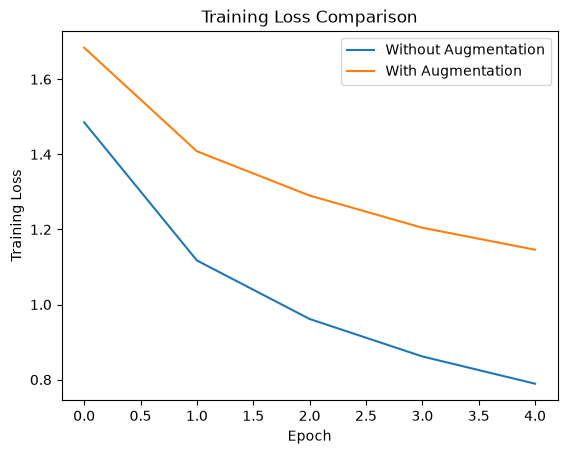

In [34]:
plt.plot(basic_losses, label="Without Augmentation")
plt.plot(augmented_losses, label="With Augmentation")

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Comparison")

plt.legend()
plt.show()